# 注意力机制与 Transformer

> **斯坦福 CS231n Lecture 8** | Attention and Transformers

## 本章导读

Transformer 架构已超越 CNN 成为视觉领域的主流模型。本节从自注意力机制出发，手算 QKV 计算，然后从零实现 Multi-Head Attention，最后理解 ViT 如何将 Transformer 应用于图像。

**学习目标：**
- 理解 Self-Attention 的 QKV 模型
- 从零实现 Multi-Head Attention
- 理解 ViT 的 Patch Embedding

**参考来源：** [Attention is All You Need](https://arxiv.org/abs/1706.03762) | [ViT](https://arxiv.org/abs/2010.11929)

## 1. Self-Attention 机制

### 核心公式

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

- $Q = X W_Q$：Query，「我在找什么」
- $K = X W_K$：Key，「我有什么」
- $V = X W_V$：Value，「我的内容」
- $\sqrt{d_k}$：缩放因子，防止点积过大

### 直觉理解

Self-Attention 让序列中的每个位置都可以「看到」所有其他位置，并根据相关性加权聚合信息。这解决了 RNN 的长距离依赖问题。

## 2. 手算验证

### 单头注意力计算

设 $d_k = 2$，序列长度 $N = 2$：

$$Q = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}, \quad K = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}, \quad V = \begin{bmatrix} 1 \\ 2 \end{bmatrix}

$$

1. $QK^T = \begin{bmatrix} 2 & 1 \\ 1 & 1 \end{bmatrix}$

2. $\frac{QK^T}{\sqrt{2}} = \begin{bmatrix} 1.41 & 0.71 \\ 0.71 & 0.71 \end{bmatrix}$

3. softmax 行归一化：
   - 第一行：$\text{softmax}([1.41, 0.71]) \approx [0.67, 0.33]$
   - 第二行：$\text{softmax}([0.71, 0.71]) = [0.50, 0.50]$

4. 输出 $= A \cdot V$
   - 第一个位置：$0.67 \times 1 + 0.33 \times 2 = 1.33$
   - 第二个位置：$0.50 \times 1 + 0.50 \times 2 = 1.50$

In [4]:
# 从零实现 Self-Attention
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def self_attention(Q, K, V, mask=None):
    """缩放点积注意力
    Q, K, V: (N, d)
    返回: (N, d_v), attention_weights (N, N)
    """
    d_k = K.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)  # (N, N)
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    attention = softmax(scores, axis=-1)  # (N, N)
    out = attention @ V  # (N, d_v)
    return out, attention

# 验证手算结果
Q = np.array([[1, 0], [0, 1]], dtype=float)
K = np.array([[1, 1], [0, 1]], dtype=float)
V = np.array([[1], [2]], dtype=float)
out, attn = self_attention(Q, K, V)
print(f"注意力权重:\n{attn}")
print(f"输出: {out.flatten()}")
print(f"期望输出: [1.33, 1.50]")

注意力权重:
[[0.66976155 0.33023845]
 [0.5        0.5       ]]
输出: [1.33023845 1.5       ]
期望输出: [1.33, 1.50]


In [5]:
# 从零实现 Multi-Head Attention
def multi_head_attention(X, W_Q, W_K, W_V, W_O, num_heads=4):
    """多头注意力
    X: (N, d_model)
    W_Q, W_K, W_V: (d_model, d_model)
    W_O: (d_model, d_model)
    """
    N, d_model = X.shape
    d_k = d_model // num_heads
    
    Q = X @ W_Q  # (N, d_model)
    K = X @ W_K
    V = X @ W_V
    
    # 分割为多头
    Q = Q.reshape(N, num_heads, d_k).transpose(1, 0, 2)  # (h, N, d_k)
    K = K.reshape(N, num_heads, d_k).transpose(1, 0, 2)
    V = V.reshape(N, num_heads, d_k).transpose(1, 0, 2)
    
    # 每头注意力
    outputs = []
    attentions = []
    for h in range(num_heads):
        out_h, attn_h = self_attention(Q[h], K[h], V[h])
        outputs.append(out_h)
        attentions.append(attn_h)
    
    # 拼接 + 线性变换
    concat = np.concatenate(outputs, axis=-1)  # (N, d_model)
    out = concat @ W_O
    return out, attentions

# 测试
d_model = 64
N = 10
X = np.random.randn(N, d_model)
W_Q = np.random.randn(d_model, d_model) * 0.1
W_K = np.random.randn(d_model, d_model) * 0.1
W_V = np.random.randn(d_model, d_model) * 0.1
W_O = np.random.randn(d_model, d_model) * 0.1

out, attentions = multi_head_attention(X, W_Q, W_K, W_V, W_O, num_heads=4)
print(f"输入形状: {X.shape}")
print(f"输出形状: {out.shape}")
print(f"注意力头数: 4, 每头维度: {d_model // 4}")

输入形状: (10, 64)
输出形状: (10, 64)
注意力头数: 4, 每头维度: 16


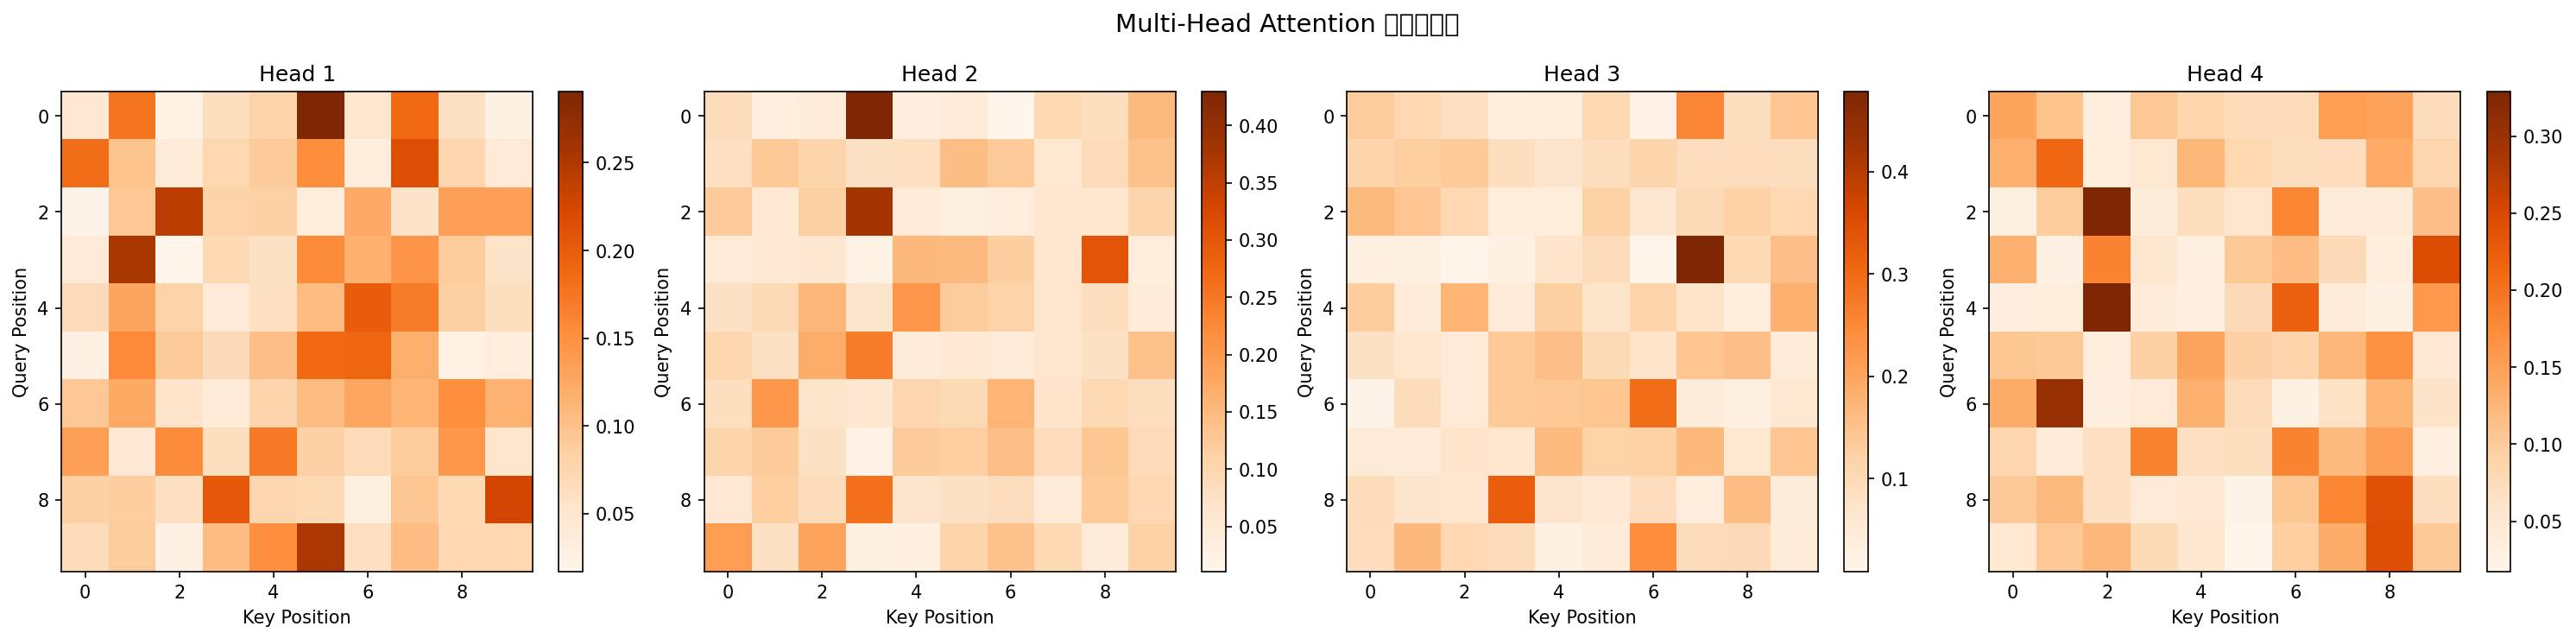

In [6]:
# 可视化注意力权重
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for h in range(4):
    im = axes[h].imshow(attentions[h], cmap='Oranges', aspect='auto')
    axes[h].set_title(f'Head {h+1}')
    axes[h].set_xlabel('Key Position')
    axes[h].set_ylabel('Query Position')
    plt.colorbar(im, ax=axes[h], fraction=0.046)
plt.suptitle('Multi-Head Attention 权重可视化', fontsize=14)
plt.tight_layout()
plt.savefig('lecture-08-transformers/attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ViT: Vision Transformer

### Patch Embedding

ViT 将图像分割为固定大小的 patch，每个 patch 展平后线性投影为向量：

$$\mathbf{z}_i = \text{Linear}(\text{flatten}(\text{patch}_i)) + \text{PE}_i$$

然后送入标准 Transformer Encoder。

[[Dosovitskiy et al., 2020]](https://arxiv.org/abs/2010.11929) ViT 论文

### CNN vs ViT 对比

| 特性 | CNN | ViT |
|------|-----|------|
| **归纳偏置** | 局部性、平移等变 | 无（全局注意力） |
| **数据效率** | 小数据即可 | 需要大数据预训练 |
| **计算量** | O(HW) | O(N²), N=patch数 |
| **感受野** | 随深度增长 | 第一层就是全局 |

ViT 放弃了 CNN 的归纳偏置，用更多数据学习——这就是「An Image is Worth 16×16 Words」。

## 作业

### 作业 1：实现 Positional Encoding

完成 ViT 中使用的正弦位置编码：

In [9]:
# 作业 1：实现 Positional Encoding
def positional_encoding(seq_len, d_model):
    """正弦位置编码
    PE[pos, 2i] = sin(pos / 10000^(2i/d_model))
    PE[pos, 2i+1] = cos(pos / 10000^(2i/d_model))
    """
    pe = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, None]
    # 在此实现
    pass
    return pe

pe = positional_encoding(10, 8)
assert pe.shape == (10, 8)
assert np.allclose(pe[0, 0], 0.0)  # sin(0) = 0
assert np.allclose(pe[0, 1], 1.0)  # cos(0) = 1
print("作业 1 通过!")

AssertionError: 

## 参考文献

1. **Attention is All You Need** - Vaswani et al., 2017. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
2. **An Image is Worth 16×16 Words (ViT)** - Dosovitskiy et al., 2020. [arXiv:2010.11929](https://arxiv.org/abs/2010.11929)
3. **The Illustrated Transformer** - Jay Alammar. [jalammar.github.io](http://jalammar.github.io/illustrated-transformer/)
4. **Attention? Attention!** - Lilian Weng. [lilianweng.github.io](https://lilianweng.github.io/posts/2018-06-24-attention/)

---

> 本节内容参考 [Stanford CS231n Lecture 8](https://cs231n.stanford.edu/)